# Enriching HBIM with FIBO — end to end

Interactive version of `src/run_enrichment.py`. We map the **HBIM business-assets
taxonomy** to **FIBO** with SKOS/RDF/annotations, reason, and turn the inferred
triples into concrete HBIM enrichment — the same graph is exported for **Protégé**
(see `PROTEGE.md`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd
from rdflib import RDFS, OWL, URIRef
from rdflib.namespace import SKOS
from enricher import OntologyEnricher, q
from common import HBIM
import viz                     # networkx diagrams

e = OntologyEnricher()
e.lift_skos_to_owl(); e.build_bridge(); e.assemble(); e.reason()
print(f"{len(e.hbim_concepts())} HBIM concepts | asserted {len(e.asserted)} "
      f"-> inferred {len(e.inferred)} (+{len(e.new)})")

7 HBIM concepts | asserted 154 -> inferred 591 (+437)


## Diagrams · the inputs

Before the numbers, two pictures of what we start with.

### The original, fabricated HBIM taxonomy
A shallow SKOS tree of business assets — `skos:broader` shown as upward edges.

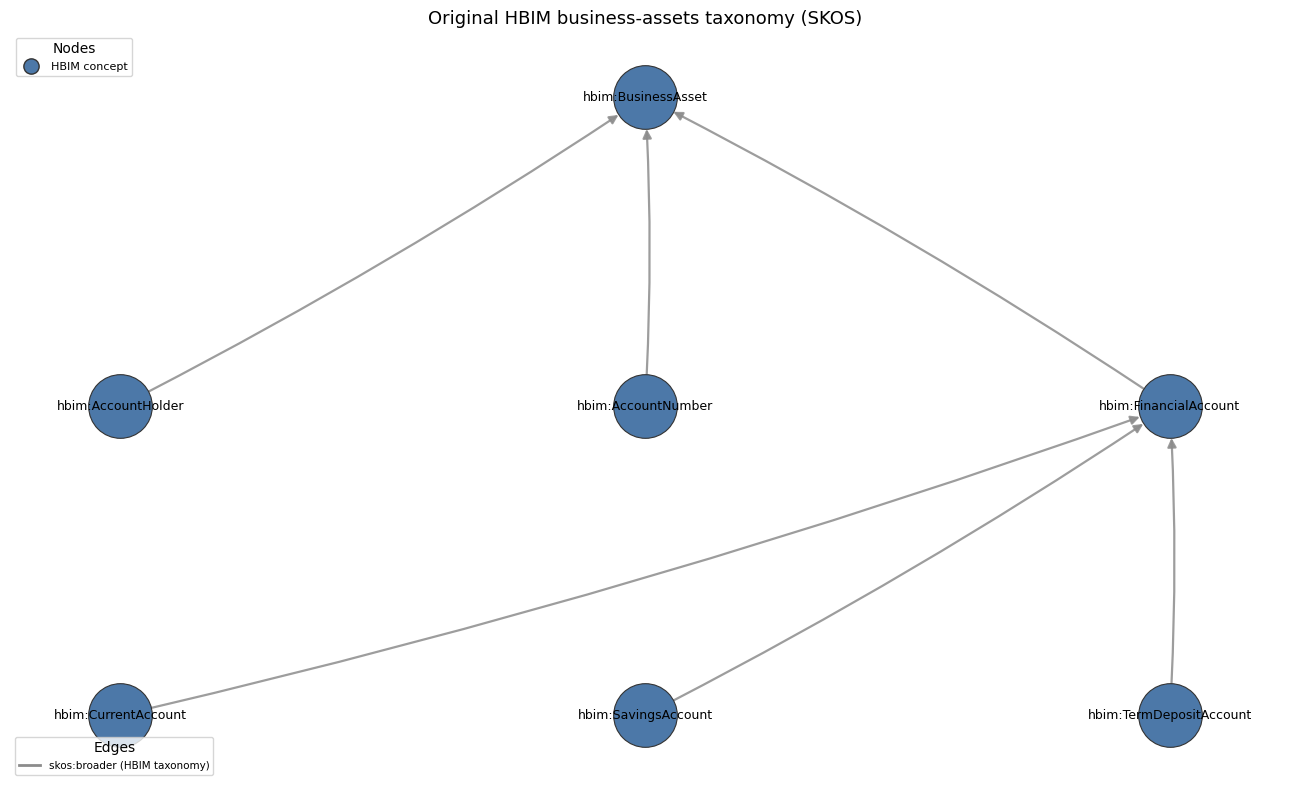

In [2]:
viz.draw_graph(viz.hbim_taxonomy_graph(e),
               "Original HBIM business-assets taxonomy (SKOS)",
               figsize=(13, 8), node_size=2100, font_size=9)

### The subset of FIBO we actually use
The real FIBO class hierarchy (`rdfs:subClassOf`, solid orange) plus the
`someValuesFrom` **restrictions** (dotted) that later become HBIM relationships.

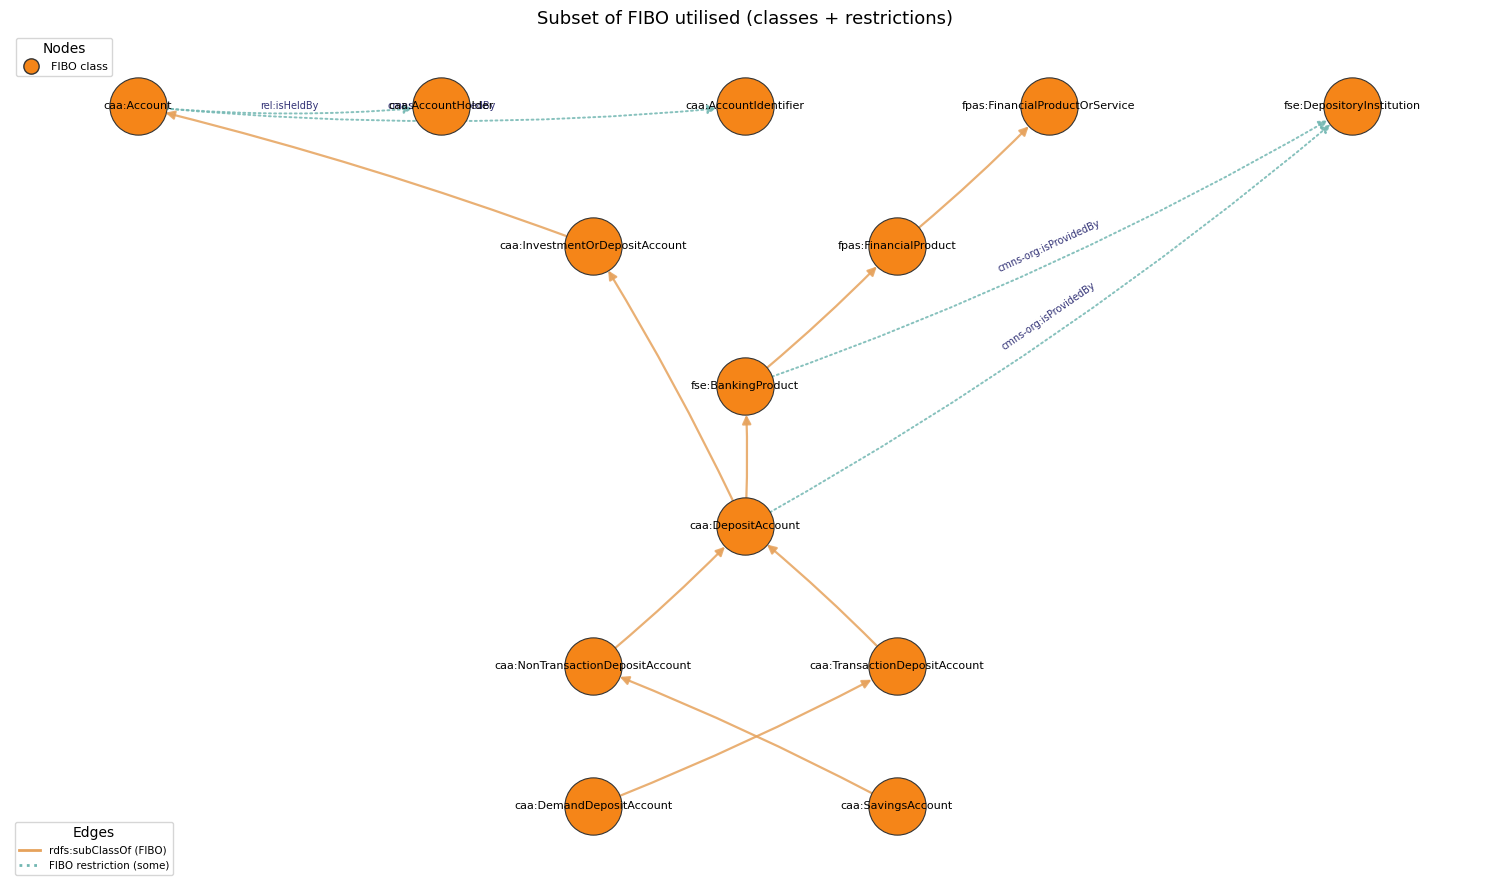

In [3]:
viz.draw_graph(viz.fibo_subset_graph(e),
               "Subset of FIBO utilised (classes + restrictions)",
               figsize=(15, 9), node_size=1700, font_size=8, edge_labels=True, x_gap=2.8)

## Scenario 1 · Lift the SKOS taxonomy to OWL (`skos:broader` → `rdfs:subClassOf`)

In [4]:
pd.DataFrame([
    {"concept": q(e.hbim, c),
     "skos:broader → rdfs:subClassOf": ", ".join(q(e.hbim, p) for p in e.hbim.objects(c, SKOS.broader))}
    for c in e.hbim_concepts()
])

,concept,skos:broader → rdfs:subClassOf
0,hbim:AccountHolder,hbim:BusinessAsset
1,hbim:AccountNumber,hbim:BusinessAsset
2,hbim:BusinessAsset,
3,hbim:CurrentAccount,hbim:FinancialAccount
4,hbim:FinancialAccount,hbim:BusinessAsset
5,hbim:SavingsAccount,hbim:FinancialAccount
6,hbim:TermDepositAccount,hbim:FinancialAccount


## Scenario 2 · Map HBIM → FIBO (SKOS) and bridge to OWL

In [5]:
pd.DataFrame(e.bridge_log)

,mapping,hbim,fibo,owl_axiom
0,skos:exactMatch,hbim:FinancialAccount,caa:Account,hbim:FinancialAccount owl:equivalentClass caa:...
1,skos:exactMatch,hbim:SavingsAccount,caa:SavingsAccount,hbim:SavingsAccount owl:equivalentClass caa:Sa...
2,skos:exactMatch,hbim:AccountHolder,caa:AccountHolder,hbim:AccountHolder owl:equivalentClass caa:Acc...
3,skos:closeMatch,hbim:CurrentAccount,caa:DemandDepositAccount,hbim:CurrentAccount rdfs:subClassOf caa:Demand...
4,skos:closeMatch,hbim:AccountNumber,caa:AccountIdentifier,hbim:AccountNumber rdfs:subClassOf caa:Account...
5,skos:broadMatch,hbim:TermDepositAccount,caa:DepositAccount,hbim:TermDepositAccount rdfs:subClassOf caa:De...
6,skos:relatedMatch,hbim:FinancialAccount,caa:AccountHolder,(none - annotation only)


## Scenario 3 · Subsumption enrichment

FIBO ancestry inferred for each HBIM concept — knowledge never asserted in the
glossary (e.g. a *Current Account* is a deposit account **and** a financial product).

In [6]:
sub = e.enrich_subsumption()
pd.DataFrame([
    {"concept": k,
     "≡ exact": ", ".join(v["equivalentTo"]),
     "⊑ mapped": ", ".join(v["mapped_parent"]),
     "⊑ INFERRED (new)": ", ".join(v["inferred_ancestors"])}
    for k, v in sub.items()
])

,concept,≡ exact,⊑ mapped,⊑ INFERRED (new)
0,hbim:AccountHolder,caa:AccountHolder,,
1,hbim:AccountNumber,,caa:AccountIdentifier,
2,hbim:CurrentAccount,,caa:DemandDepositAccount,"caa:Account, caa:DepositAccount, caa:Investmen..."
3,hbim:FinancialAccount,caa:Account,,
4,hbim:SavingsAccount,caa:SavingsAccount,,"caa:Account, caa:DepositAccount, caa:Investmen..."
5,hbim:TermDepositAccount,,caa:DepositAccount,"caa:Account, caa:InvestmentOrDepositAccount, f..."


### Diagram · the outcome of mapping + inference

HBIM concepts (blue) are mapped to FIBO (orange) — `exactMatch` as solid green,
`close`/`broadMatch` as dashed green — and the reasoner then lifts each concept
into the FIBO hierarchy: every **red dashed** edge is an *inferred* `rdfs:subClassOf`
that did not exist in the glossary.

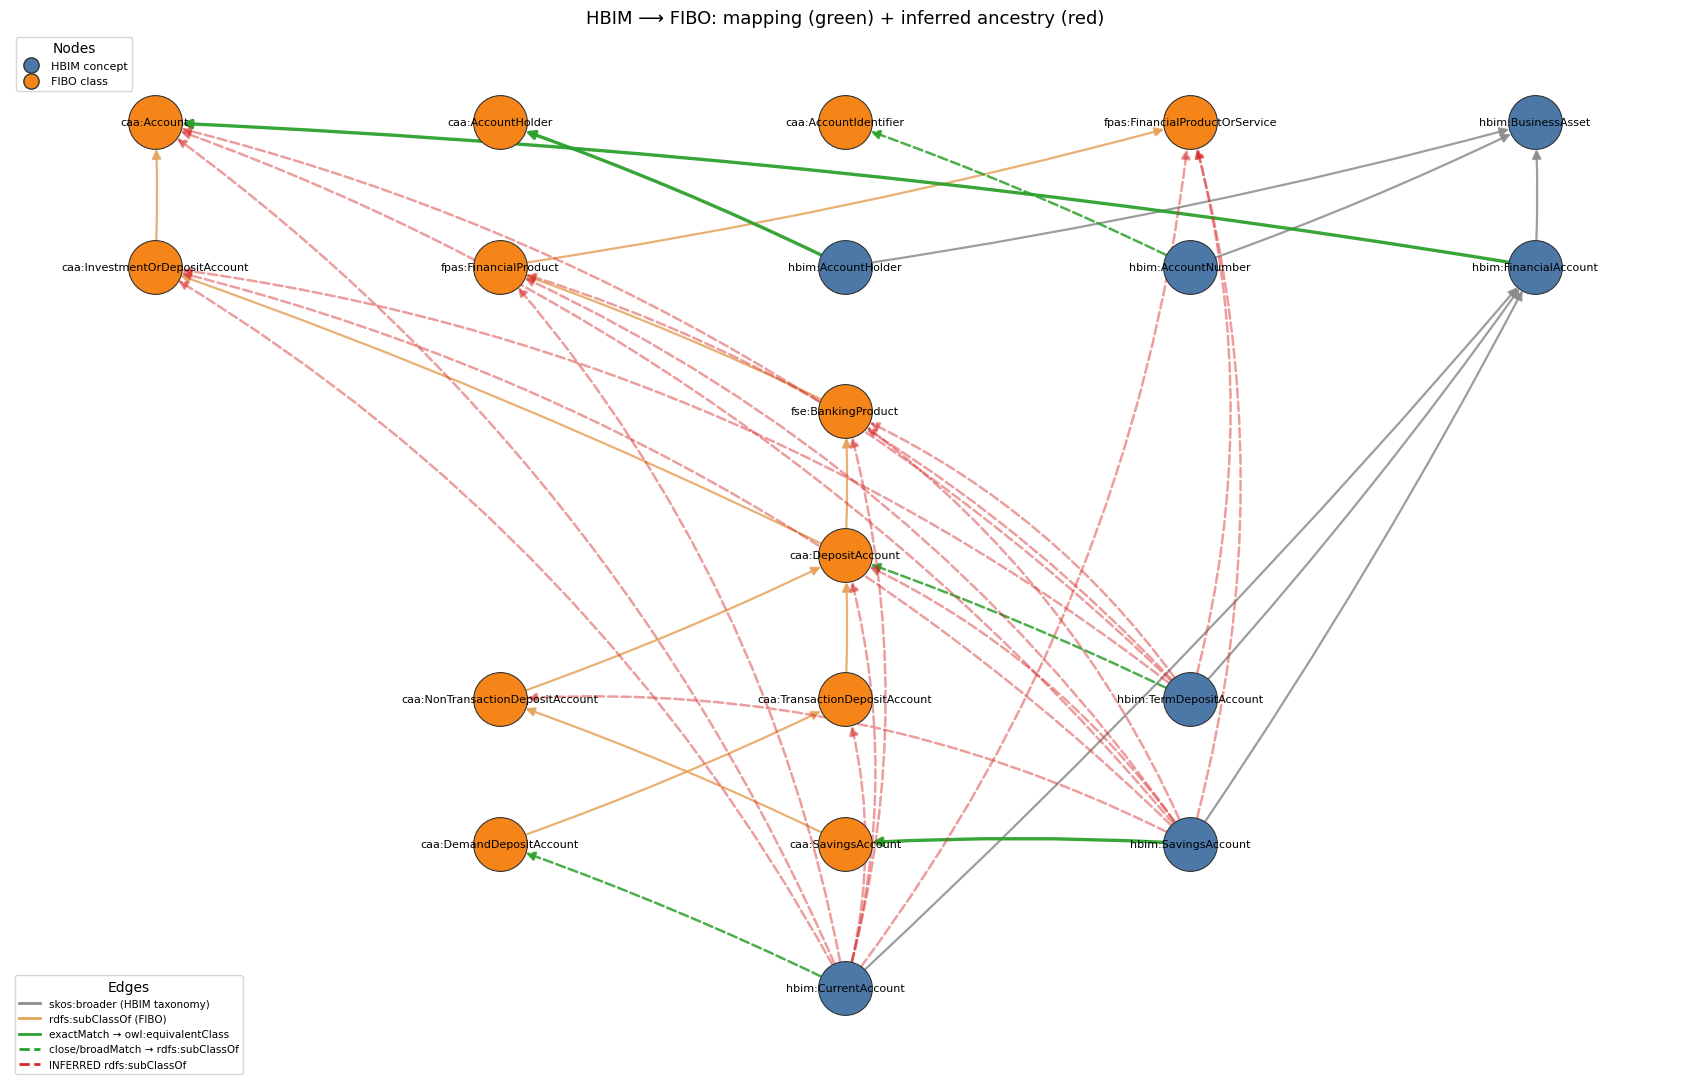

In [7]:
viz.draw_graph(viz.mapping_inference_graph(e, sub),
               "HBIM ⟶ FIBO: mapping (green) + inferred ancestry (red)",
               figsize=(17, 11), node_size=1500, font_size=8, x_gap=3.0, y_gap=1.8)

#### Focused view — how one concept gets enriched

The same story for `hbim:CurrentAccount` alone: its glossary parent (grey), the
FIBO class it maps to (green), the FIBO backbone (orange), and everything FIBO now
proves it to be (red dashed).

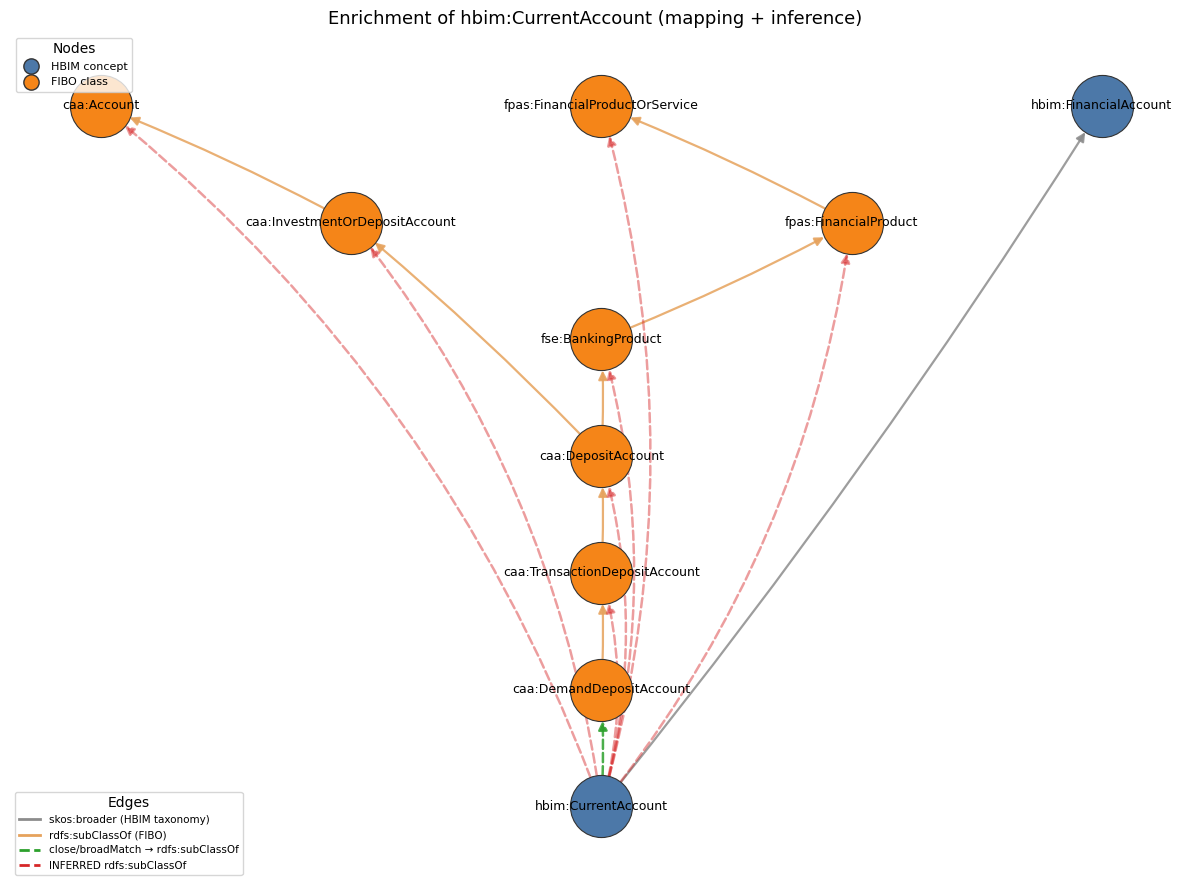

In [8]:
viz.draw_graph(viz.concept_enrichment_graph(e, sub, "CurrentAccount"),
               "Enrichment of hbim:CurrentAccount (mapping + inference)",
               figsize=(12, 9), node_size=2000, font_size=9, x_gap=2.6)

## Scenario 4 · Relationship enrichment (inherited FIBO restrictions)

In [9]:
rows = []
for c in (HBIM.FinancialAccount, HBIM.CurrentAccount, HBIM.SavingsAccount):
    for r in e.enrich_relationships(c):
        rows.append({"concept": q(e.inferred, c), "property": r["property"],
                     "must relate to": f"some {r['value_type']}"})
pd.DataFrame(rows)

,concept,property,must relate to
0,hbim:FinancialAccount,rel:isHeldBy,some caa:AccountHolder
1,hbim:FinancialAccount,cmns-id:isIdentifiedBy,some caa:AccountIdentifier
2,hbim:CurrentAccount,rel:isHeldBy,some caa:AccountHolder
3,hbim:CurrentAccount,cmns-id:isIdentifiedBy,some caa:AccountIdentifier
4,hbim:CurrentAccount,cmns-org:isProvidedBy,some fse:DepositoryInstitution
5,hbim:SavingsAccount,rel:isHeldBy,some caa:AccountHolder
6,hbim:SavingsAccount,cmns-id:isIdentifiedBy,some caa:AccountIdentifier
7,hbim:SavingsAccount,cmns-org:isProvidedBy,some fse:DepositoryInstitution


## Scenario 5 · Annotation enrichment (copy real FIBO definitions)

In [10]:
pd.DataFrame(e.enrich_annotations())

,concept,source,definition
0,hbim:AccountHolder,caa:AccountHolder,party that holds and may operate an account in...
1,hbim:AccountNumber,caa:AccountIdentifier,identifier that is unique to and used to ident...
2,hbim:CurrentAccount,caa:DemandDepositAccount,non-interest-bearing deposit account in which ...
3,hbim:FinancialAccount,caa:Account,"formal banking, brokerage, or business relatio..."
4,hbim:SavingsAccount,caa:SavingsAccount,"interest-bearing deposit account, held at a ba..."
5,hbim:TermDepositAccount,caa:DepositAccount,deposit-based product involving funds placed i...


## Scenario 6 · Instance classification (a real account reclassified via FIBO)

In [11]:
inst = e.enrich_instances()
pd.DataFrame([
    {"individual": ind, "inferred FIBO type": t, "new": t in info["newly_inferred"]}
    for ind, info in inst.items() for t in info["inferred_fibo_types"]
])

,individual,inferred FIBO type,new
0,hbim:acct-GB29NWBK60161331926819,caa:Account,True
1,hbim:acct-GB29NWBK60161331926819,caa:DemandDepositAccount,True
2,hbim:acct-GB29NWBK60161331926819,caa:DepositAccount,True
3,hbim:acct-GB29NWBK60161331926819,caa:InvestmentOrDepositAccount,True
4,hbim:acct-GB29NWBK60161331926819,caa:TransactionDepositAccount,True
5,hbim:acct-GB29NWBK60161331926819,fpas:FinancialProduct,True
6,hbim:acct-GB29NWBK60161331926819,fpas:FinancialProductOrService,True
7,hbim:acct-GB29NWBK60161331926819,fse:BankingProduct,True


## Scenario 7 · Validation — FIBO disjointness catches an HBIM mapping error

We inject `hbim:CurrentAccount ⊑ caa:NonTransactionDepositAccount` (wrong — a
current account is *transactional*). FIBO declares the two disjoint, so the
reasoner rejects it.

In [12]:
clashes = e.validate_with_disjointness()
pd.DataFrame(clashes) if clashes else "consistent"

,offending,disjoint_a,disjoint_b
0,hbim:acct-GB29NWBK60161331926819,caa:TransactionDepositAccount,caa:NonTransactionDepositAccount
1,hbim:CurrentAccount,caa:TransactionDepositAccount,caa:NonTransactionDepositAccount


## Write the artifacts (enriched HBIM + Protégé-ready OWL)

In [13]:
from common import HBIM_ENRICHED, PROTEGE_TTL, PROTEGE_RDF, INFERRED_TTL
enriched = e.build_enriched_hbim(sub, e.enrich_annotations())
enriched.serialize(destination=HBIM_ENRICHED, format="turtle")
e.asserted.serialize(destination=PROTEGE_TTL, format="turtle")
e.asserted.serialize(destination=PROTEGE_RDF, format="xml")
e.inferred.serialize(destination=INFERRED_TTL, format="turtle")
print("wrote enriched HBIM + Protégé bundle. See PROTEGE.md to reproduce in Protégé.")

wrote enriched HBIM + Protégé bundle. See PROTEGE.md to reproduce in Protégé.


### The enriched `hbim:CurrentAccount` — before vs after

Below is the enriched concept: original SKOS + the mapping + **materialised FIBO
ancestry** (`rdfs:subClassOf` / `skos:broadMatch`) + a **definition copied from
FIBO** with a provenance note.

In [14]:
ca = HBIM.CurrentAccount
pd.DataFrame([
    {"predicate": enriched.qname(p),
     "object": (enriched.qname(o) if isinstance(o, URIRef) else f'"{str(o)[:70]}"')}
    for p, o in sorted(enriched.predicate_objects(ca), key=lambda x: str(x[0]))
])

,predicate,object
0,rdf:type,skos:Concept
1,rdfs:seeAlso,caa:DemandDepositAccount
2,rdfs:subClassOf,caa:Account
3,rdfs:subClassOf,caa:DepositAccount
4,rdfs:subClassOf,caa:InvestmentOrDepositAccount
5,rdfs:subClassOf,caa:TransactionDepositAccount
6,rdfs:subClassOf,fpas:FinancialProduct
7,rdfs:subClassOf,fpas:FinancialProductOrService
8,rdfs:subClassOf,fse:BankingProduct
9,skos:altLabel,"""Checking Account"""
